# Part a)

## Imports

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import brentq

## Parameters

In [12]:
# Kinetic parameters
mu_m = 0.9        # h^-1
Ks = 0.21        # g/L
KI = 1.5         # g/L
Yxs = 0.6        # g/g
KCL = 0.2        # mg/L
Yos = 160        # mg/g
M = 0.0314

# Reactor parameters
VL = 90          # L
G = 5000         # L/h
eps = 0.2
CLi = 6          # mg/L
CGi = 250        # mg/L
Si = 30          # g/L
VG = eps * VL
CL_limit = 3 * KCL

## Initial conditions

In [13]:
y0 = [1, 0, 6, 250]  # X, S, CL, CG

## Model equations

In [14]:
# Growth rate
def mu(S, CL):
    return mu_m * S / (Ks + S + S**2 / KI) * CL / (KCL + CL)

# ODE system
def system(t, y, F, KLa):
    X, S, CL, CG = y

    # Prevent numerical negative concentrations
    X = max(X, 0)
    S = max(S, 0)
    CL = max(CL, 0)
    CG = max(CG, 0)

    mu_val = mu(S, CL) if S > 0 else 0
    CL_star = M * CG

    dXdt = -F / VL * X + mu_val * X

    dSdt = F / VL * (Si - S) - (1 / Yxs) * mu_val * X

    dCLdt = (F / VL * (CLi - CL) - Yos / Yxs * mu_val * X + KLa * (CL_star - CL))

    dCGdt = (G / VG * (CGi - CG) - KLa * VL / VG * (CL_star - CL))

    return [dXdt, dSdt, dCLdt, dCGdt]

## Numerical solver

In [15]:
def simulate(F, KLa, t_end=600):
    t_eval = np.linspace(0, t_end, 1200)

    sol = solve_ivp(system, [0, t_end], y0, args=(F, KLa), method="BDF", rtol=1e-6, atol=1e-6, t_eval=t_eval)

    return sol

## Oxygen Limitation Criterion

In [16]:
# Minimum dissolved oxygen
def min_CL(F, KLa):
    sol = simulate(F, KLa)
    return np.min(sol.y[2])

# Search for minimum KLa
def find_min_KLa(F):
    def condition(KLa):
        return min_CL(F, KLa) - CL_limit

    # Increase upper bound if needed
    KLa_low = 0.01
    KLa_high = 70

    while condition(KLa_high) < 0:
        KLa_high *= 2

    return brentq(condition, KLa_low, KLa_high)

## Simulation for Different Feed Flow Rates

In [17]:
F_values = np.linspace(6.5, 10, 8)

results = []

for F in F_values:
    KLa_needed = find_min_KLa(F)
    sol = simulate(F, KLa_needed)
    CL_min = np.min(sol.y[2])

    results.append([F, KLa_needed, CL_min])

print("F [L/h]      KLa_min [h^-1]      min(CL) [mg/L]")
for F, KLa_needed, CL_min in results:
    print(f"{F:6.2f}      {KLa_needed:12.3f}      {CL_min:12.3f}")

F [L/h]      KLa_min [h^-1]      min(CL) [mg/L]
  6.50           131.779             0.600
  7.00            16.016             0.600
  7.50            15.708             0.600
  8.00            15.366             0.600
  8.50            15.002             0.600
  9.00            14.627             0.600
  9.50            14.248             0.600
 10.00            13.871             0.600


## Growth Kinetics Analysis for F = 10 L/h

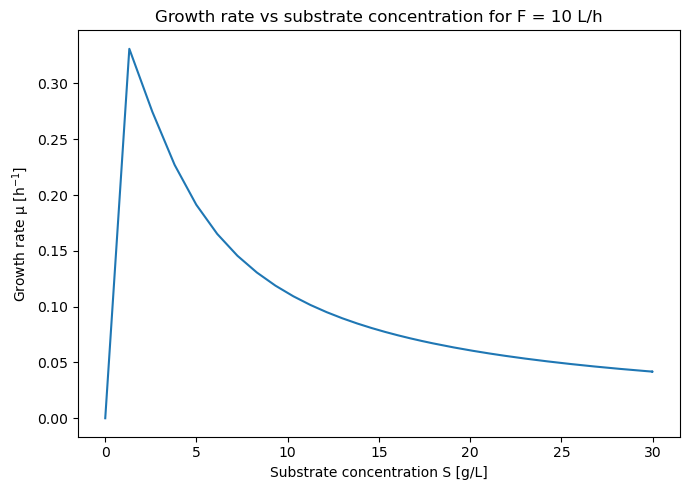

In [18]:
# Simulation
F_plot = 10
KLa_plot = find_min_KLa(F_plot)
sol = simulate(F_plot, KLa_plot)

X = sol.y[0]
S = sol.y[1]
CL = sol.y[2]

mu_values = mu(S, CL)

# Plot of growth rate vs substrate concentration
plt.figure(figsize=(7, 5))
plt.plot(S, mu_values)
plt.xlabel("Substrate concentration S [g/L]")
plt.ylabel("Growth rate μ [h$^{-1}$]")
plt.title("Growth rate vs substrate concentration for F = 10 L/h")
plt.grid(False)
plt.tight_layout()
plt.show()